# LLM Model Comparison: GPT vs Claude vs Gemini

Analyzes the main pipeline run (wave `2026-05-27`) across three datasets:
- **`global_opinion_qa`** — WVS opinion questions; models return probability distributions compared against the human global distribution
- **`persona_prompts`** — free-text responses under three SES conditions (baseline / high_ses / low_ses)

**Models:** ChatGPT-5.3, Claude Sonnet 4.6, Gemini Pro  
**Experiment baseline:** Gemini 2.0 Flash Lite (included for contrast)

---
### Measures
| Section | Measure |
|---|---|
| A. Opinion QA | Jensen-Shannon Divergence from human distribution |
| A. Opinion QA | Earth Mover's Distance (respects ordinal scale) |
| A. Opinion QA | Mode agreement rate with human mode |
| A. Opinion QA | Entropy of model vs human distributions |
| A. Opinion QA | Pairwise inter-model correlation |
| A. Opinion QA | Mean probability mass on refusal options (DK/NA) |
| B. Persona Prompts | Pairwise cosine similarity between models (embeddings) |
| B. Persona Prompts | SES condition drift (embedding distance from baseline) |
| B. Persona Prompts | Response length per model × condition |
| B. Persona Prompts | Lexical diversity (TTR, Distinct-2) |
| B. Persona Prompts | Sentiment (VADER) per model × condition |
| C. Operations | Latency, token counts, truncation rate |

In [1]:
import sqlite3, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, spearmanr, pearsonr
from scipy.stats import wasserstein_distance
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DB_PATH  = 'study.db'
WAVE     = '2026-05-27'
MODELS   = ['Gpt 5.3 Chat', 'Claude Sonnet', 'Gemini Pro']
PALETTE  = {'Gpt 5.3 Chat': '#10A37F', 'Claude Sonnet': '#C97037', 'Gemini Pro': '#4285F4',
            'Gemini 2.0 Flash Lite': '#AAAAAA'}

con = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

/home/ckoban/longitudinal-llm-study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected to study.db


## 0 · Load Data

In [2]:
# ── All responses for the target wave ─────────────────────────────────────────
df_raw = pd.read_sql_query("""
    SELECT
        rr.id,
        sw.name          AS wave,
        mc.display_name  AS model,
        di.dataset_name  AS dataset,
        di.item_id       AS item_id,
        di.prompt_text,
        di.metadata,
        di.system_text,
        rr.response_text,
        rr.input_tokens,
        rr.output_tokens,
        rr.latency_ms,
        rr.finish_reason,
        rr.error
    FROM response_records rr
    JOIN study_waves   sw ON rr.wave_id          = sw.id
    JOIN model_configs mc ON rr.model_config_id  = mc.id
    JOIN dataset_items di ON rr.item_id          = di.id
    WHERE sw.name = ?
""", con, params=(WAVE,))

df_raw['metadata_parsed'] = df_raw['metadata'].apply(json.loads)
print(f"{len(df_raw):,} rows  |  models: {sorted(df_raw['model'].unique())}")
df_raw.groupby(['model','dataset'])['id'].count().unstack(fill_value=0)

2,549 rows  |  models: ['Claude Sonnet', 'Gemini 2.0 Flash Lite', 'Gemini Pro', 'Gpt 5.3 Chat']


dataset,global_opinion_qa,persona_prompts
model,,
Claude Sonnet,352,300
Gemini 2.0 Flash Lite,293,300
Gemini Pro,352,300
Gpt 5.3 Chat,352,300


In [3]:
# ── Split by dataset ───────────────────────────────────────────────────────────
df_oqa  = df_raw[df_raw['dataset'] == 'global_opinion_qa'].copy()
df_pers = df_raw[df_raw['dataset'] == 'persona_prompts'].copy()

# Parse condition from persona metadata
df_pers['condition'] = df_pers['metadata_parsed'].apply(lambda m: m.get('condition'))
df_pers['query_source'] = df_pers['metadata_parsed'].apply(lambda m: m.get('query_source'))

# Focus on main 3 models for opinion QA
df_oqa_main  = df_oqa[df_oqa['model'].isin(MODELS)].copy()
df_pers_main = df_pers[df_pers['model'].isin(MODELS)].copy()

print('global_opinion_qa (main 3):', len(df_oqa_main))
print('persona_prompts  (main 3):', len(df_pers_main))

global_opinion_qa (main 3): 1056
persona_prompts  (main 3): 900


## A · Global Opinion QA — Distributional Analysis

Each response is a probability distribution over multiple-choice options.  
The metadata contains the **actual global human distribution** (`global_distribution`).

In [4]:
# ── Parse model probability distributions ─────────────────────────────────────
def parse_prob_dist(text):
    """Extract JSON dict from response, return sorted list of floats or None."""
    if not isinstance(text, str):
        return None
    m = re.search(r'\{[^{}]+\}', text, re.DOTALL)
    if not m:
        return None
    try:
        d = json.loads(m.group())
        vals = [float(v) for v in d.values()]
        if sum(vals) == 0:
            return None
        return vals
    except Exception:
        return None

def align_dists(model_vals, human_vals):
    """Pad shorter distribution with zeros so both have equal length."""
    n = max(len(model_vals), len(human_vals))
    m = np.array(model_vals + [0.0] * (n - len(model_vals)), dtype=float)
    h = np.array(human_vals + [0.0] * (n - len(human_vals)), dtype=float)
    # Normalise (guard against sum=0)
    if m.sum() > 0: m = m / m.sum()
    if h.sum() > 0: h = h / h.sum()
    return m, h

df_oqa_main['model_dist'] = df_oqa_main['response_text'].apply(parse_prob_dist)
df_oqa_main['human_dist'] = df_oqa_main['metadata_parsed'].apply(
    lambda m: m.get('global_distribution'))
df_oqa_main['human_entropy_raw'] = df_oqa_main['metadata_parsed'].apply(
    lambda m: m.get('entropy'))

# Drop rows where parsing failed
valid = df_oqa_main.dropna(subset=['model_dist', 'human_dist'])
print(f"Valid rows: {len(valid)} / {len(df_oqa_main)}  (parse success rate: {len(valid)/len(df_oqa_main):.1%})")
valid.groupby('model')['id'].count()

Valid rows: 1030 / 1056  (parse success rate: 97.5%)


model
Claude Sonnet    352
Gemini Pro       326
Gpt 5.3 Chat     352
Name: id, dtype: int64

In [5]:
# ── Compute per-item metrics ───────────────────────────────────────────────────
rows = []
for _, r in valid.iterrows():
    m_dist, h_dist = align_dists(r['model_dist'], list(r['human_dist']))
    # JSD (scipy returns sqrt-JSD; square to get proper JSD in [0,1])
    jsd = jensenshannon(m_dist, h_dist) ** 2
    # Earth Mover's Distance
    positions = np.arange(len(m_dist))
    emd = wasserstein_distance(positions, positions, m_dist, h_dist)
    # Entropy
    m_ent = entropy(m_dist + 1e-12)
    h_ent = entropy(h_dist + 1e-12)
    # Mode agreement
    mode_match = int(np.argmax(m_dist) == np.argmax(h_dist))
    # Refusal mass (last 2 options are typically DK/NA/Missing)
    refusal_mass = float(sum(m_dist[-2:]))
    rows.append(dict(
        item_id=r['item_id'], model=r['model'],
        jsd=jsd, emd=emd,
        model_entropy=m_ent, human_entropy=h_ent,
        entropy_delta=m_ent - h_ent,
        mode_match=mode_match,
        refusal_mass=refusal_mass
    ))

metrics = pd.DataFrame(rows)
print(metrics.groupby('model')[['jsd','emd','mode_match','entropy_delta','refusal_mass']].mean().round(4))

                  jsd     emd  mode_match  entropy_delta  refusal_mass
model                                                                 
Claude Sonnet  0.0618  0.6138      0.5369        -0.0473        0.0925
Gemini Pro     0.1145  0.7494      0.4939        -0.2939        0.1329
Gpt 5.3 Chat   0.1640  1.0518      0.4545        -0.4080        0.1229


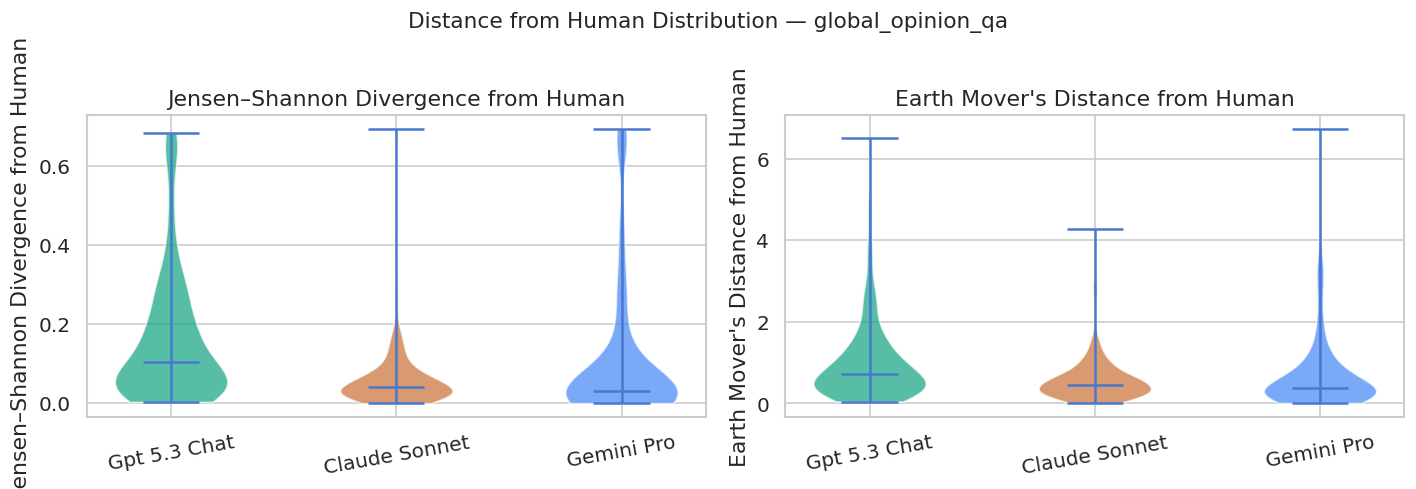

In [6]:
# ── Plot A1: JSD and EMD from human distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes,
                          ['jsd',  'emd'],
                          ['Jensen–Shannon Divergence from Human', 'Earth Mover\'s Distance from Human']):
    data = [metrics.loc[metrics['model'] == m, col].dropna().values for m in MODELS]
    parts = ax.violinplot(data, positions=range(len(MODELS)), showmedians=True)
    for i, (pc, m) in enumerate(zip(parts['bodies'], MODELS)):
        pc.set_facecolor(PALETTE[m])
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(MODELS, rotation=10)
    ax.set_ylabel(label)
    ax.set_title(label)

plt.suptitle('Distance from Human Distribution — global_opinion_qa', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

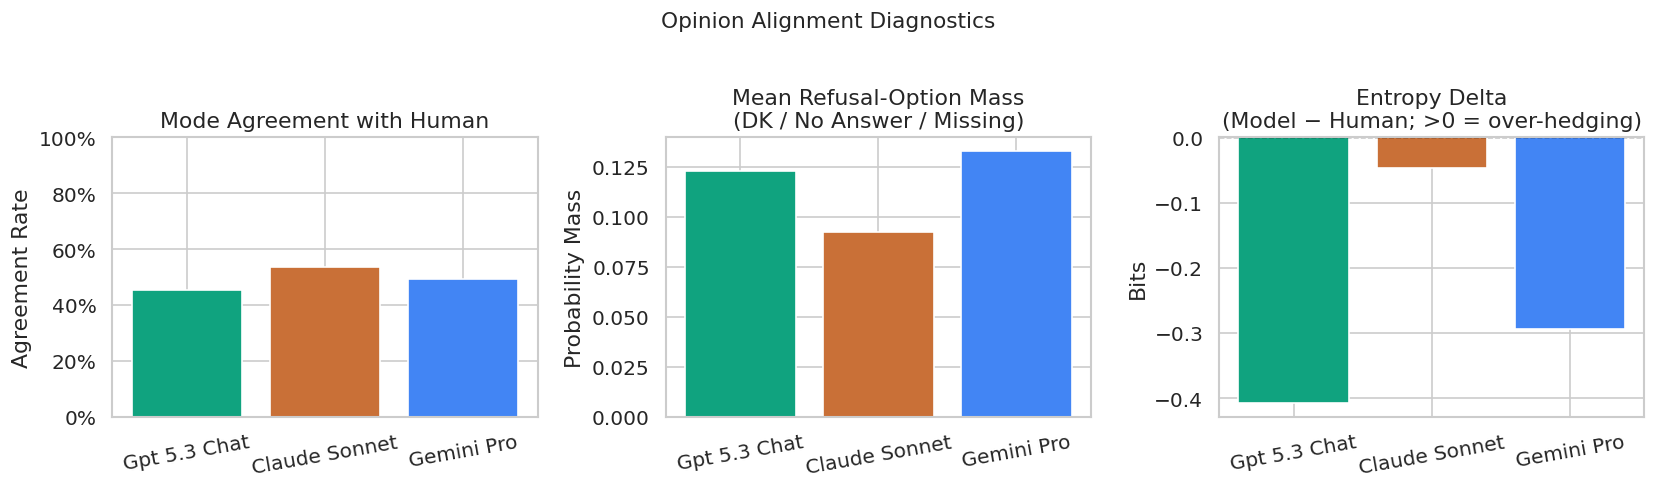

In [7]:
# ── Plot A2: Mode agreement rate & refusal mass ────────────────────────────────
summary = metrics.groupby('model')[['mode_match','refusal_mass','entropy_delta']].mean().loc[MODELS]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = [PALETTE[m] for m in MODELS]

axes[0].bar(MODELS, summary['mode_match'], color=colors)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title('Mode Agreement with Human')
axes[0].set_ylabel('Agreement Rate')
axes[0].set_ylim(0, 1)

axes[1].bar(MODELS, summary['refusal_mass'], color=colors)
axes[1].set_title('Mean Refusal-Option Mass\n(DK / No Answer / Missing)')
axes[1].set_ylabel('Probability Mass')

axes[2].bar(MODELS, summary['entropy_delta'], color=colors)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Entropy Delta\n(Model − Human; >0 = over-hedging)')
axes[2].set_ylabel('Bits')

for ax in axes:
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Opinion Alignment Diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Items with all 3 models: 326


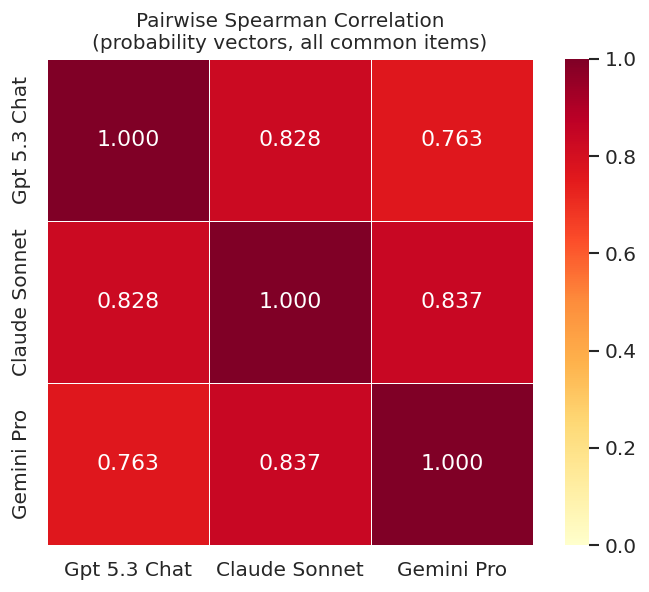

,Gpt 5.3 Chat,Claude Sonnet,Gemini Pro
Gpt 5.3 Chat,1.000000,0.827714,0.763426
Claude Sonnet,0.827714,1.000000,0.836673
Gemini Pro,0.763426,0.836673,1.000000


In [8]:
# ── A3: Pairwise inter-model correlation ──────────────────────────────────────
# Build per-item probability vectors aligned to maximum option count
def dist_vector(vals, n):
    v = np.array(list(vals) + [0.0] * (n - len(vals)), dtype=float)
    if v.sum() > 0: v /= v.sum()
    return v

# Pivot: rows = item_id, cols = model, values = dist vector
max_opts = valid['model_dist'].apply(len).max()

pivot = {}
for m in MODELS:
    sub = valid[valid['model'] == m].set_index('item_id')
    pivot[m] = sub['model_dist'].apply(lambda v: dist_vector(v, max_opts))

# Keep only items present in all 3 models
common_items = set(pivot[MODELS[0]].index)
for m in MODELS[1:]:
    common_items &= set(pivot[m].index)
common_items = sorted(common_items)
print(f"Items with all 3 models: {len(common_items)}")

# Flatten distributions per item → long vectors, then Spearman correlation
M = {m: np.vstack([pivot[m].loc[i] for i in common_items]).flatten() for m in MODELS}

corr_matrix = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for m1 in MODELS:
    for m2 in MODELS:
        r, _ = spearmanr(M[m1], M[m2])
        corr_matrix.loc[m1, m2] = r

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Pairwise Spearman Correlation\n(probability vectors, all common items)', fontsize=12)
plt.tight_layout()
plt.show()
corr_matrix

## B · Persona Prompts — Semantic & Lexical Analysis

In [9]:
# ── Load sentence embeddings ───────────────────────────────────────────────────
print('Loading sentence-transformer model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Only use clean (non-error) responses
df_pers_clean = df_pers_main[df_pers_main['error'].isna() &
                             df_pers_main['response_text'].notna()].copy()

texts = df_pers_clean['response_text'].tolist()
embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=32)
df_pers_clean = df_pers_clean.copy()
df_pers_clean['embedding'] = list(embeddings)

print(f"Embedded {len(df_pers_clean)} responses")

Loading sentence-transformer model...


Batches: 100%|██████████| 29/29 [25:46<00:00, 53.34s/it]


Embedded 899 responses


898 pairwise similarities


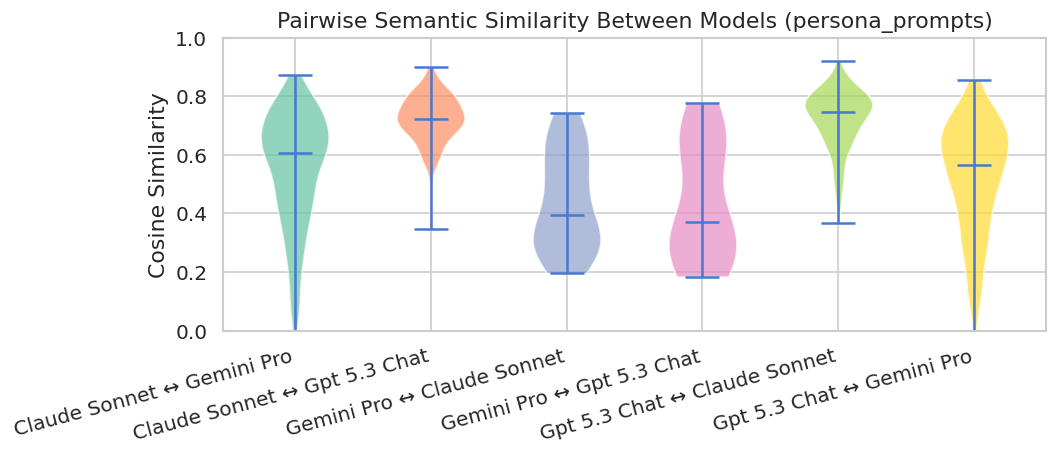

,mean,median,std
pair,,,
Claude Sonnet ↔ Gemini Pro,0.552,0.605,0.195
Claude Sonnet ↔ Gpt 5.3 Chat,0.716,0.724,0.094
Gemini Pro ↔ Claude Sonnet,0.440,0.396,0.168
Gemini Pro ↔ Gpt 5.3 Chat,0.440,0.372,0.204
Gpt 5.3 Chat ↔ Claude Sonnet,0.721,0.748,0.104
Gpt 5.3 Chat ↔ Gemini Pro,0.525,0.564,0.191


In [10]:
# ── B1: Pairwise model cosine similarity ──────────────────────────────────────
# For each item_id present in multiple models, compute cosine sim between each model pair
from itertools import combinations

sim_rows = []
for item_id, grp in df_pers_clean.groupby('item_id'):
    models_present = grp['model'].tolist()
    if len(models_present) < 2:
        continue
    emb_map = dict(zip(grp['model'], grp['embedding']))
    cond = grp['condition'].iloc[0]
    qsrc = grp['query_source'].iloc[0]
    for m1, m2 in combinations(emb_map.keys(), 2):
        sim = float(cosine_similarity([emb_map[m1]], [emb_map[m2]])[0, 0])
        sim_rows.append(dict(item_id=item_id, model_a=m1, model_b=m2,
                             pair=f'{m1} ↔ {m2}', cosine_sim=sim,
                             condition=cond, query_source=qsrc))

df_sim = pd.DataFrame(sim_rows)
print(f"{len(df_sim)} pairwise similarities")

fig, ax = plt.subplots(figsize=(9, 4))
pairs = sorted(df_sim['pair'].unique())
pair_colors = sns.color_palette('Set2', len(pairs))
data_by_pair = [df_sim.loc[df_sim['pair'] == p, 'cosine_sim'].values for p in pairs]
parts = ax.violinplot(data_by_pair, positions=range(len(pairs)), showmedians=True)
for pc, c in zip(parts['bodies'], pair_colors):
    pc.set_facecolor(c); pc.set_alpha(0.7)
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pairs, rotation=15, ha='right')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Pairwise Semantic Similarity Between Models (persona_prompts)')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

df_sim.groupby('pair')['cosine_sim'].agg(['mean','median','std']).round(3)

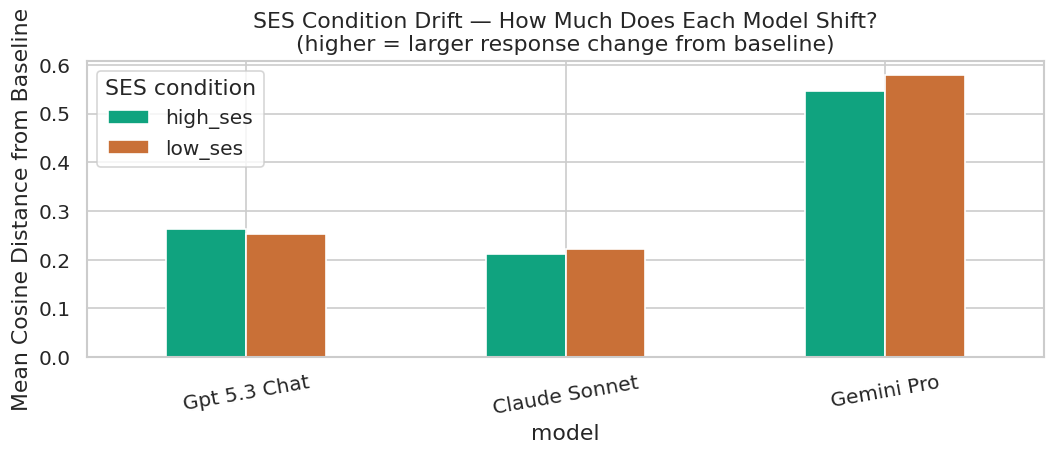

condition,high_ses,low_ses
model,,
Gpt 5.3 Chat,0.2629,0.2537
Claude Sonnet,0.2125,0.2217
Gemini Pro,0.5452,0.5794


In [11]:
# ── B2: SES Condition Drift ────────────────────────────────────────────────────
# For each (model, item query_id), compute embedding distance from baseline to high/low SES

def query_key(row):
    """Stable key that links the same underlying query across conditions."""
    m = row['metadata_parsed']
    return (m.get('query_source'), m.get('query_id'))

df_pers_clean['query_key'] = df_pers_clean.apply(query_key, axis=1)

# Keep only baseline / high_ses / low_ses (drop customer/user sub-conditions for clarity)
core_conds = ['baseline', 'high_ses', 'low_ses']
df_core = df_pers_clean[df_pers_clean['condition'].isin(core_conds)].copy()

drift_rows = []
for (model, qkey), grp in df_core.groupby(['model', 'query_key']):
    cond_map = dict(zip(grp['condition'], grp['embedding']))
    if 'baseline' not in cond_map:
        continue
    base_emb = cond_map['baseline']
    for tgt_cond in ['high_ses', 'low_ses']:
        if tgt_cond in cond_map:
            sim = float(cosine_similarity([base_emb], [cond_map[tgt_cond]])[0, 0])
            drift_rows.append(dict(model=model, query_key=qkey,
                                   condition=tgt_cond, drift=1 - sim))

df_drift = pd.DataFrame(drift_rows)

fig, ax = plt.subplots(figsize=(9, 4))
pivot_drift = df_drift.groupby(['model','condition'])['drift'].mean().unstack()
pivot_drift = pivot_drift.loc[MODELS] if all(m in pivot_drift.index for m in MODELS) else pivot_drift
pivot_drift.plot(kind='bar', ax=ax,
                 color=[PALETTE.get(m, '#888') for m in pivot_drift.index],
                 edgecolor='white')
ax.set_ylabel('Mean Cosine Distance from Baseline')
ax.set_title('SES Condition Drift — How Much Does Each Model Shift?\n(higher = larger response change from baseline)')
ax.tick_params(axis='x', rotation=10)
ax.legend(title='SES condition')
plt.tight_layout()
plt.show()

pivot_drift.round(4)

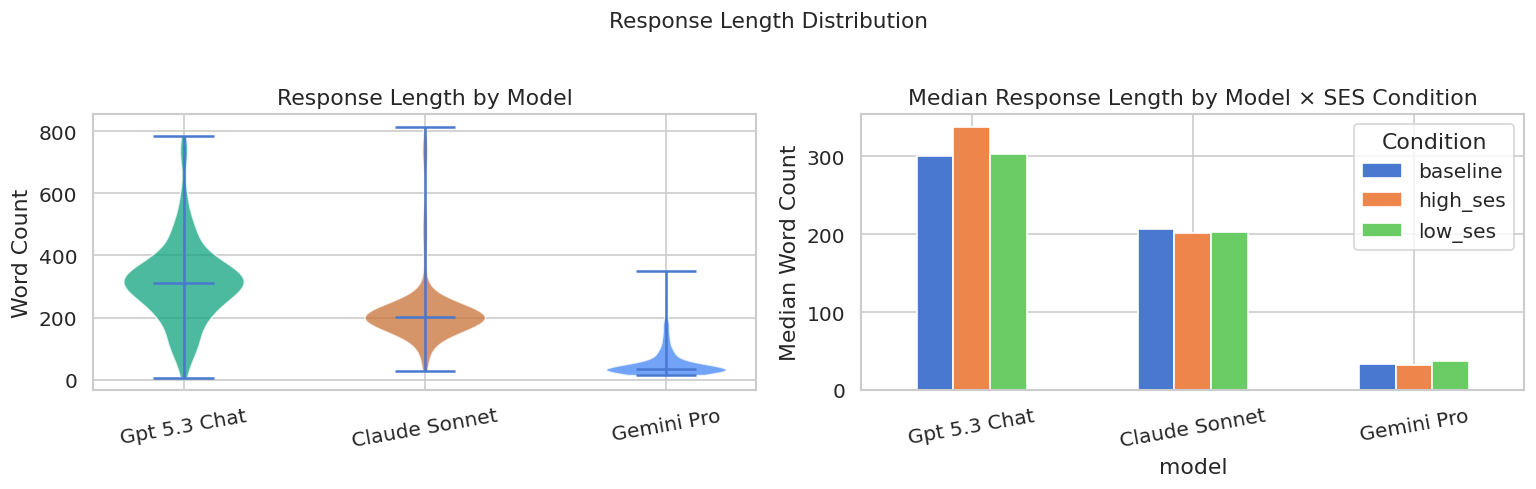

In [12]:
# ── B3: Response Length ────────────────────────────────────────────────────────
df_pers_clean['word_count'] = df_pers_clean['response_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

# By model
order = MODELS
data_model = [df_pers_clean.loc[df_pers_clean['model']==m, 'word_count'].dropna() for m in order]
parts = axes[0].violinplot(data_model, positions=range(len(order)), showmedians=True)
for pc, m in zip(parts['bodies'], order):
    pc.set_facecolor(PALETTE[m]); pc.set_alpha(0.75)
axes[0].set_xticks(range(len(order))); axes[0].set_xticklabels(order, rotation=10)
axes[0].set_ylabel('Word Count'); axes[0].set_title('Response Length by Model')

# By condition × model
sub = df_pers_clean[df_pers_clean['condition'].isin(core_conds)]
pivot_len = sub.groupby(['model','condition'])['word_count'].median().unstack()
pivot_len = pivot_len.reindex(MODELS)
pivot_len.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_ylabel('Median Word Count')
axes[1].set_title('Median Response Length by Model × SES Condition')
axes[1].tick_params(axis='x', rotation=10)
axes[1].legend(title='Condition')

plt.suptitle('Response Length Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

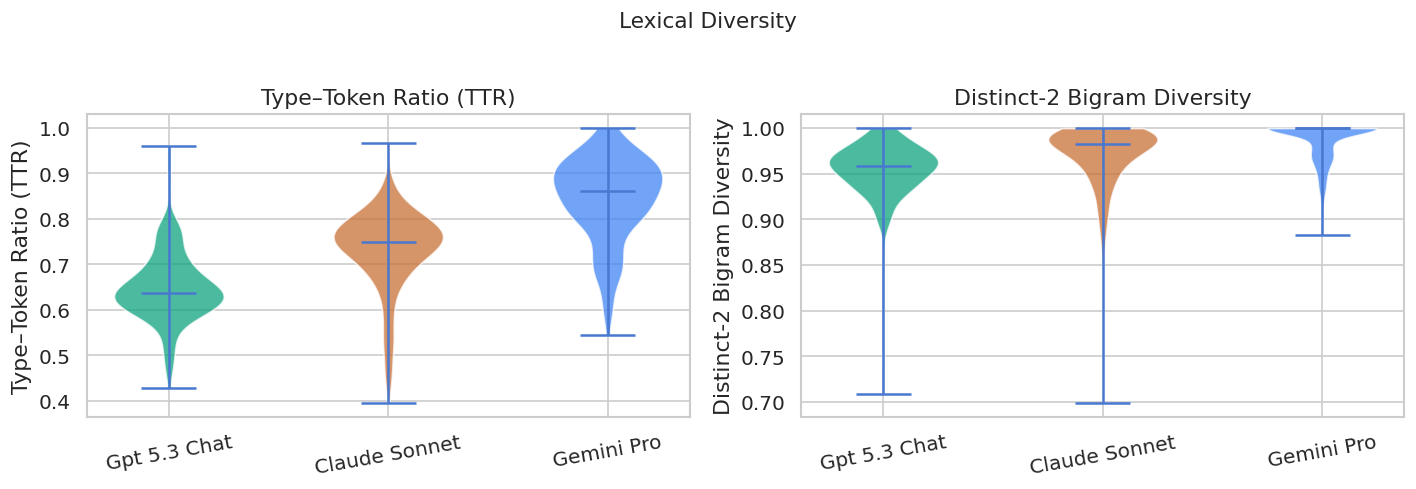

,ttr,distinct_2
model,,
Gpt 5.3 Chat,0.650,0.953
Claude Sonnet,0.730,0.969
Gemini Pro,0.843,0.986


In [13]:
# ── B4: Lexical Diversity ──────────────────────────────────────────────────────
def type_token_ratio(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    if len(tokens) < 10: return np.nan
    return len(set(tokens)) / len(tokens)

def distinct_2(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    bigrams = list(zip(tokens, tokens[1:]))
    if len(bigrams) == 0: return np.nan
    return len(set(bigrams)) / len(bigrams)

df_pers_clean['ttr']        = df_pers_clean['response_text'].apply(type_token_ratio)
df_pers_clean['distinct_2'] = df_pers_clean['response_text'].apply(distinct_2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['ttr','distinct_2'],
                                  ['Type–Token Ratio (TTR)', 'Distinct-2 Bigram Diversity']):
    data = [df_pers_clean.loc[df_pers_clean['model']==m, col].dropna() for m in MODELS]
    parts = ax.violinplot(data, positions=range(len(MODELS)), showmedians=True)
    for pc, m in zip(parts['bodies'], MODELS):
        pc.set_facecolor(PALETTE[m]); pc.set_alpha(0.75)
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=10)
    ax.set_ylabel(label); ax.set_title(label)

plt.suptitle('Lexical Diversity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

df_pers_clean.groupby('model')[['ttr','distinct_2']].mean().loc[MODELS].round(3)

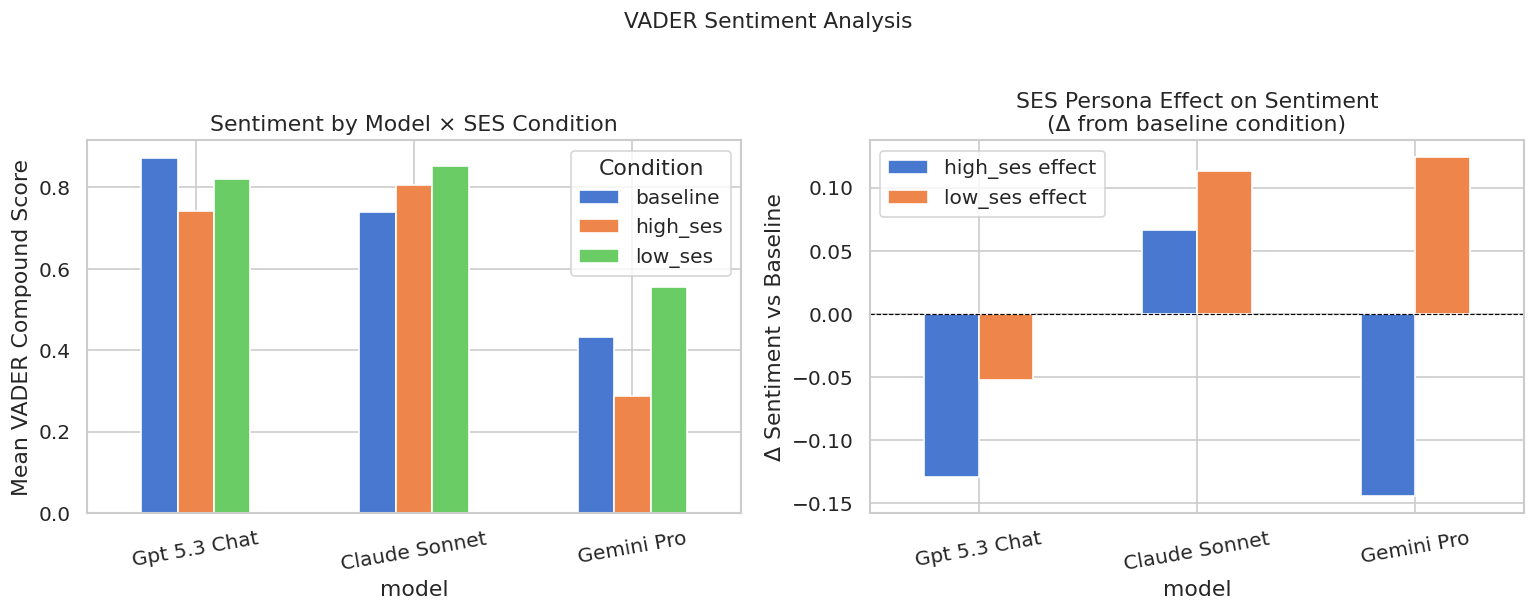

condition,baseline,high_ses,low_ses
model,,,
Gpt 5.3 Chat,0.871,0.742,0.819
Claude Sonnet,0.740,0.806,0.853
Gemini Pro,0.432,0.288,0.556


In [14]:
# ── B5: Sentiment (VADER) by Model × Condition ────────────────────────────────
sia = SentimentIntensityAnalyzer()

def vader_compound(text):
    if not isinstance(text, str) or len(text) == 0:
        return np.nan
    return sia.polarity_scores(text)['compound']

df_pers_clean['sentiment'] = df_pers_clean['response_text'].apply(vader_compound)

sub_sent = df_pers_clean[df_pers_clean['condition'].isin(core_conds)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: mean sentiment by model × condition (bar)
pivot_sent = sub_sent.groupby(['model','condition'])['sentiment'].mean().unstack()
pivot_sent = pivot_sent.reindex(MODELS)
pivot_sent.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_ylabel('Mean VADER Compound Score')
axes[0].set_title('Sentiment by Model × SES Condition')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend(title='Condition')

# Panel 2: condition effect (high_ses − baseline, low_ses − baseline) per model
baseline_sent = pivot_sent['baseline']
effect = pd.DataFrame({
    'high_ses effect': pivot_sent.get('high_ses', np.nan) - baseline_sent,
    'low_ses effect':  pivot_sent.get('low_ses', np.nan)  - baseline_sent,
}).dropna(how='all')
effect.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_ylabel('Δ Sentiment vs Baseline')
axes[1].set_title('SES Persona Effect on Sentiment\n(Δ from baseline condition)')
axes[1].tick_params(axis='x', rotation=10)
axes[1].legend(title='')

plt.suptitle('VADER Sentiment Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pivot_sent.round(3)

## C · Operational Metrics

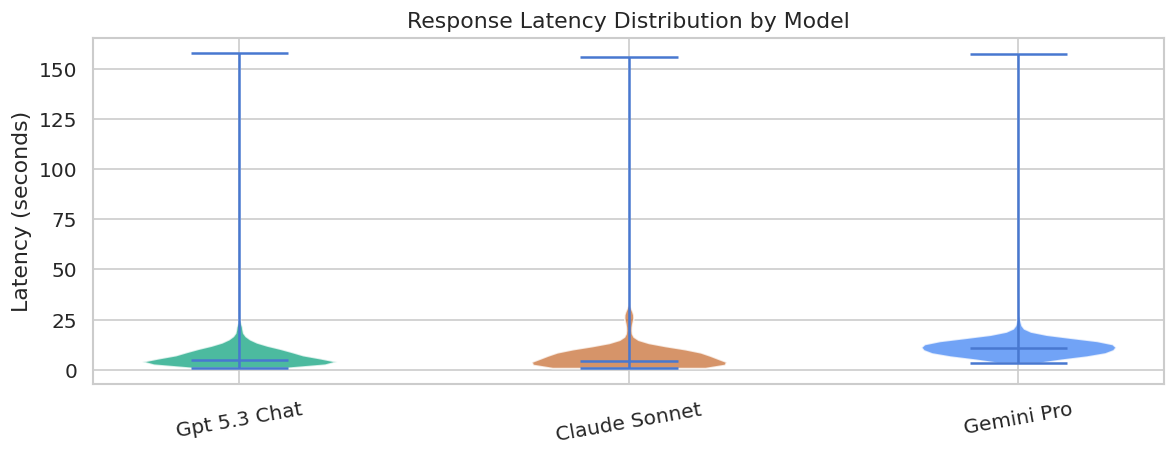

In [15]:
# ── C1: Latency distribution ───────────────────────────────────────────────────
all_models = df_raw['model'].unique().tolist()
palette_ext = {**PALETTE}

fig, ax = plt.subplots(figsize=(10, 4))
data_lat = [df_raw.loc[(df_raw['model']==m) & df_raw['latency_ms'].notna(), 'latency_ms'] / 1000
            for m in MODELS]
parts = ax.violinplot(data_lat, positions=range(len(MODELS)), showmedians=True)
for pc, m in zip(parts['bodies'], MODELS):
    pc.set_facecolor(PALETTE[m]); pc.set_alpha(0.75)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=10)
ax.set_ylabel('Latency (seconds)')
ax.set_title('Response Latency Distribution by Model')
plt.tight_layout()
plt.show()

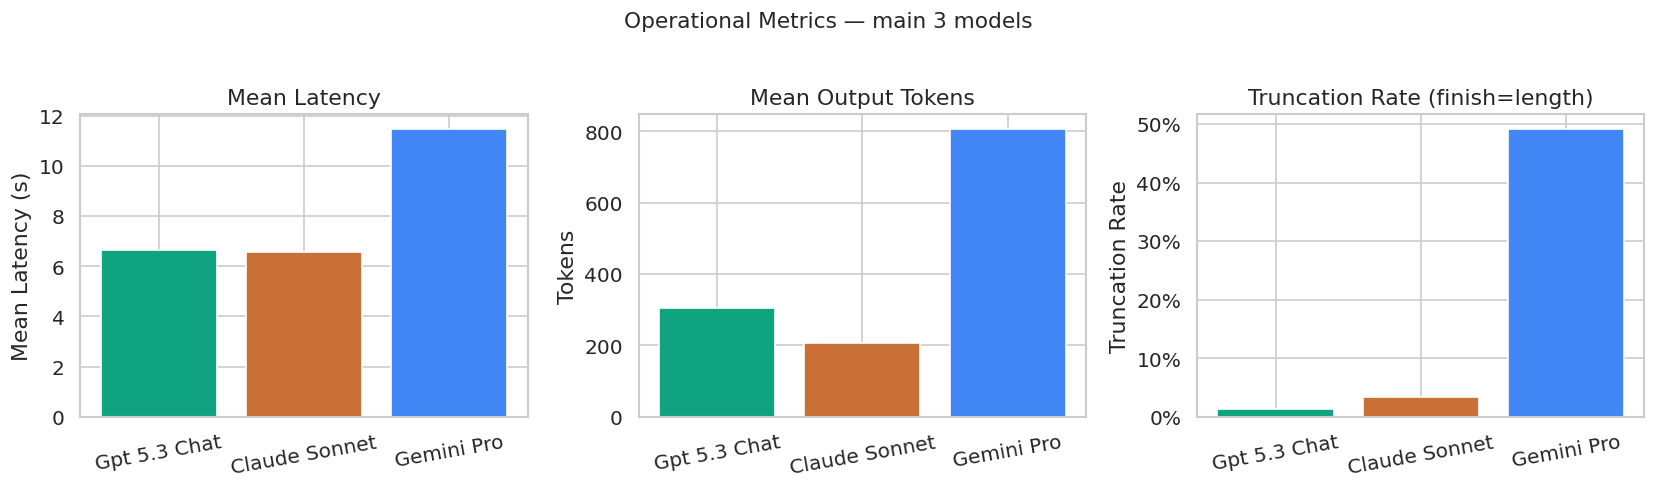

,mean_latency_s,median_latency_s,mean_input_tok,mean_output_tok,truncation_rate,n_responses
model,,,,,,
Gpt 5.3 Chat,6.651,4.875,113.948,305.563,0.014,652
Claude Sonnet,6.548,4.460,121.422,206.385,0.034,652
Gemini Pro,11.477,10.950,110.931,807.442,0.492,652


In [16]:
# ── C2: Token counts and truncation rate ──────────────────────────────────────
ops = df_raw[df_raw['model'].isin(MODELS)].copy()
ops['truncated'] = (ops['finish_reason'] == 'length').astype(int)

op_summary = ops.groupby('model').agg(
    mean_latency_s  = ('latency_ms',   lambda x: x.mean() / 1000),
    median_latency_s= ('latency_ms',   lambda x: x.median() / 1000),
    mean_input_tok  = ('input_tokens',  'mean'),
    mean_output_tok = ('output_tokens', 'mean'),
    truncation_rate = ('truncated',     'mean'),
    n_responses     = ('id',            'count'),
).loc[MODELS].round(3)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bar_kw = dict(edgecolor='white')

colors = [PALETTE[m] for m in op_summary.index]
axes[0].bar(op_summary.index, op_summary['mean_latency_s'], color=colors, **bar_kw)
axes[0].set_ylabel('Mean Latency (s)'); axes[0].set_title('Mean Latency')
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(op_summary.index, op_summary['mean_output_tok'], color=colors, **bar_kw)
axes[1].set_ylabel('Tokens'); axes[1].set_title('Mean Output Tokens')
axes[1].tick_params(axis='x', rotation=10)

axes[2].bar(op_summary.index, op_summary['truncation_rate'], color=colors, **bar_kw)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[2].set_ylabel('Truncation Rate'); axes[2].set_title('Truncation Rate (finish=length)')
axes[2].tick_params(axis='x', rotation=10)

plt.suptitle('Operational Metrics — main 3 models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

op_summary

## Summary Table

In [17]:
# ── Aggregate summary across all sections ─────────────────────────────────────
oqa_agg = metrics.groupby('model')[['jsd','emd','mode_match','entropy_delta','refusal_mass']].mean()
pers_agg = df_pers_clean.groupby('model')[['word_count','ttr','distinct_2','sentiment']].mean()
ops_agg  = op_summary[['mean_latency_s','mean_output_tok','truncation_rate']]

summary_all = oqa_agg.join(pers_agg, how='outer').join(ops_agg, how='outer')
summary_all = summary_all.reindex(MODELS)
summary_all.round(3).style.background_gradient(cmap='RdYlGn_r', axis=0,
    subset=['jsd','emd','refusal_mass','truncation_rate']) \
    .background_gradient(cmap='RdYlGn', axis=0,
    subset=['mode_match','ttr','distinct_2'])

,jsd,emd,mode_match,entropy_delta,refusal_mass,word_count,ttr,distinct_2,sentiment,mean_latency_s,mean_output_tok,truncation_rate
model,,,,,,,,,,,,
Gpt 5.3 Chat,0.164000,1.052000,0.455000,-0.408000,0.123000,314.993000,0.650000,0.953000,0.811000,6.651000,305.563000,0.014000
Claude Sonnet,0.062000,0.614000,0.537000,-0.047000,0.092000,235.183000,0.730000,0.969000,0.800000,6.548000,206.385000,0.034000
Gemini Pro,0.115000,0.749000,0.494000,-0.294000,0.133000,56.763000,0.843000,0.986000,0.426000,11.477000,807.442000,0.492000
